# Real-Time ASL Sign Language Recognition
## RT-SLR-LDL — ASL Baseline (Massey University Dataset)

**Dataset:** Massey University ASL Dataset
- 36 classes: digits `0–9` + letters `a–z`
- Folder structure: `asl_dataset/0/`, `asl_dataset/1/`, ... `asl_dataset/a/`, `asl_dataset/b/` ...
- Image format: `.jpeg` (cropped hand segments)

**Pipeline:**
```
asl_dataset/ → MediaPipe Hands → Normalize → SQLite → Train → Evaluate → Live Demo
```

**Targets (Chapter 3):**
- Top-1 accuracy ≥ 90% (NFR-02)
- Inference latency ≤ 100ms on CPU (NFR-01)
- Model file size ≤ 25MB (NFR-03)

---
# 0. Setup Paths

In [1]:
import os, sys

# --- Verify environment ---
print('Python:', sys.version)

# --- Dataset path ---
# Point this to the folder that contains subfolders 0,1,...9,a,b,...z
# Adjust if your unzipped folder is in a different location
DATASET_PATH = 'asl_dataset'   # <-- change this if needed

# --- Project paths ---
WORKSPACE_PATH   = 'RT_SLR/workspace'
MODEL_PATH       = WORKSPACE_PATH + '/models'
DATA_PATH        = WORKSPACE_PATH + '/data'
SESSION_LOG_PATH = WORKSPACE_PATH + '/logs'
DB_PATH          = WORKSPACE_PATH + '/asl_slr.db'
LABEL_MAP_PATH   = DATA_PATH + '/asl_label_map.json'

# --- Model config ---
MODEL_NAME  = 'asl_classifier_v1'
MODEL_FILE  = MODEL_PATH + f'/{MODEL_NAME}.h5'
TFLITE_FILE = MODEL_PATH + f'/{MODEL_NAME}.tflite'

# --- Recognition config ---
CONFIDENCE_THRESHOLD = 0.80
SMOOTHING_WINDOW     = 5
FEATURE_SIZE         = 21 * 3   # 63 — 21 landmarks x (x,y,z)

# --- Training config ---
# Start with 200 per class for a quick smoke test
# Raise to 0 (no cap) for the full training run
MAX_IMAGES_PER_CLASS = 200
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

for path in [MODEL_PATH, DATA_PATH, SESSION_LOG_PATH]:
    os.makedirs(path, exist_ok=True)

# --- Confirm dataset is reachable ---
if os.path.isdir(DATASET_PATH):
    found = sorted(os.listdir(DATASET_PATH))
    print(f'Dataset found at: {os.path.abspath(DATASET_PATH)}')
    print(f'Subfolders ({len(found)}): {found}')
else:
    print(f'ERROR: Dataset not found at "{DATASET_PATH}"')
    print('Update DATASET_PATH to the folder containing 0,1,...,a,b,...,z subfolders')

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Dataset found at: c:\Users\HP\Documents\HANDTRACK\asl_dataset
Subfolders (37): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'asl_dataset', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


---
# 1. Install Dependencies

In [2]:
!pip install tensorflow==2.19.1 mediapipe opencv-python numpy scikit-learn tqdm matplotlib pandas

# Verify after install
import tensorflow as tf
import mediapipe as mp
import cv2
print('TensorFlow:', tf.__version__)
print('MediaPipe :', mp.__version__)
print('OpenCV    :', cv2.__version__)

TensorFlow: 2.19.1
MediaPipe : 0.10.13
OpenCV    : 4.13.0


---
# 2. Label Map — 36 ASL Classes (0–9, a–z)

In [3]:
import json

# 36 classes — digits first, then lowercase letters
# These must match the subfolder names in your dataset exactly
ASL_CLASSES = [str(i) for i in range(10)] + [chr(c) for c in range(ord('a'), ord('z') + 1)]

GESTURE_CLASSES = [
    {'class_id': i, 'class_label': label, 'language': 'ASL'}
    for i, label in enumerate(ASL_CLASSES)
]

ID_TO_LABEL = {g['class_id']: g['class_label'] for g in GESTURE_CLASSES}
LABEL_TO_ID = {g['class_label']: g['class_id'] for g in GESTURE_CLASSES}
NUM_CLASSES = len(GESTURE_CLASSES)

with open(LABEL_MAP_PATH, 'w') as f:
    json.dump(GESTURE_CLASSES, f, indent=2)

print(f'{NUM_CLASSES} classes: {ASL_CLASSES}')

# Verify all class folders exist in dataset
missing = [c for c in ASL_CLASSES if not os.path.isdir(os.path.join(DATASET_PATH, c))]
if missing:
    print(f'WARNING: Missing folders for classes: {missing}')
    print('These classes will be skipped during ingestion.')
else:
    print('All 36 class folders confirmed in dataset.')

36 classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
All 36 class folders confirmed in dataset.


---
# 3. Initialize SQLite Database

In [4]:
import sqlite3

conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

cur.executescript('''
    CREATE TABLE IF NOT EXISTS gesture_classes (
        class_id    INTEGER PRIMARY KEY,
        class_label VARCHAR(100) NOT NULL UNIQUE,
        language    VARCHAR(50)  NOT NULL,
        num_samples INTEGER DEFAULT 0
    );
    CREATE TABLE IF NOT EXISTS landmark_samples (
        sample_id INTEGER PRIMARY KEY AUTOINCREMENT,
        class_id  INTEGER NOT NULL,
        landmarks TEXT    NOT NULL,
        split     VARCHAR(10) CHECK(split IN ("train","val","test")),
        timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
        FOREIGN KEY (class_id) REFERENCES gesture_classes(class_id)
    );
    CREATE TABLE IF NOT EXISTS session_log (
        log_id          INTEGER PRIMARY KEY AUTOINCREMENT,
        session_id      VARCHAR(36) NOT NULL,
        predicted_label VARCHAR(100) NOT NULL,
        confidence      FLOAT CHECK(confidence BETWEEN 0.0 AND 1.0),
        timestamp       DATETIME DEFAULT CURRENT_TIMESTAMP
    );
    CREATE TABLE IF NOT EXISTS model_registry (
        model_id      INTEGER PRIMARY KEY AUTOINCREMENT,
        model_name    VARCHAR(100) NOT NULL UNIQUE,
        file_path     VARCHAR(255) NOT NULL,
        test_accuracy FLOAT
    );
''')

for g in GESTURE_CLASSES:
    cur.execute(
        'INSERT OR IGNORE INTO gesture_classes (class_id, class_label, language) VALUES (?,?,?)',
        (g['class_id'], g['class_label'], g['language'])
    )
conn.commit()
print(f'Database ready: {DB_PATH}')

Database ready: RT_SLR/workspace/asl_slr.db


---
# 4. MediaPipe Hands — Landmark Extraction & Normalization

In [5]:
import mediapipe as mp
import numpy as np
import cv2

mp_hands   = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

# static_image_mode=True for batch image ingestion
# Will switch to False in Cell 11 for live webcam
hands_detector = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

def extract_landmarks(frame_rgb):
    """Run MediaPipe on an RGB frame. Returns landmark object or None."""
    results = hands_detector.process(frame_rgb)
    if results.multi_hand_landmarks:
        return results.multi_hand_landmarks[0]
    return None

def normalize_landmarks(hand_landmarks):
    """
    Normalize 21 3D landmarks to a 63-element feature vector.
    - Translate: wrist (landmark 0) becomes origin
    - Scale: divide by max distance from wrist
    """
    coords  = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark])
    coords -= coords[0]                                       # wrist to origin
    scale   = np.max(np.linalg.norm(coords, axis=1)) + 1e-6  # hand size scale
    coords /= scale
    return coords.flatten()  # shape: (63,)

# Quick sanity check on one image
test_class  = ASL_CLASSES[0]   # class '0'
test_dir    = os.path.join(DATASET_PATH, test_class)
test_file   = os.listdir(test_dir)[0]
test_img    = cv2.imread(os.path.join(test_dir, test_file))
test_rgb    = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
test_lm     = extract_landmarks(test_rgb)

if test_lm:
    vec = normalize_landmarks(test_lm)
    print(f'Sanity check PASSED on class "{test_class}" image: {test_file}')
    print(f'Feature vector shape: {vec.shape}  range: [{vec.min():.3f}, {vec.max():.3f}]')
else:
    print(f'WARNING: MediaPipe could not detect hand in test image "{test_file}"')
    print('This is normal for some images. Ingestion will skip these automatically.')

Sanity check PASSED on class "0" image: hand1_0_bot_seg_1_cropped.jpeg
Feature vector shape: (63,)  range: [-0.660, 0.852]


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


---
# 5. Ingest Dataset

Reads all `.jpeg` images from each class folder, runs MediaPipe,
and stores normalized 63-element vectors in `landmark_samples`.

Images where MediaPipe cannot detect a hand are skipped automatically.

> Set `MAX_IMAGES_PER_CLASS = 200` for a quick first run.  
> Set `MAX_IMAGES_PER_CLASS = 0` to use every image in the dataset.

In [6]:
import random
from tqdm import tqdm

def assign_split(idx, total):
    r = idx / total
    if r < TRAIN_RATIO:               return 'train'
    elif r < TRAIN_RATIO + VAL_RATIO: return 'val'
    else:                             return 'test'


def ingest_dataset(dataset_path=DATASET_PATH, max_per_class=MAX_IMAGES_PER_CLASS):
    total_saved   = 0
    total_skipped = 0
    skip_report   = {}

    for class_label in ASL_CLASSES:
        class_id  = LABEL_TO_ID[class_label]
        class_dir = os.path.join(dataset_path, class_label)

        if not os.path.isdir(class_dir):
            print(f'Skipping "{class_label}" — folder not found.')
            continue

        # Collect all jpeg images in this class folder
        images = [
            f for f in os.listdir(class_dir)
            if f.lower().endswith(('.jpeg', '.jpg', '.png'))
        ]
        random.shuffle(images)
        if max_per_class > 0:
            images = images[:max_per_class]

        saved   = 0
        skipped = 0

        for idx, fname in enumerate(tqdm(images, desc=f'  {class_label:>3}', leave=False)):
            img = cv2.imread(os.path.join(class_dir, fname))
            if img is None:
                skipped += 1
                continue

            frame_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            lm        = extract_landmarks(frame_rgb)

            if lm is None:    # MediaPipe could not detect hand — skip
                skipped += 1
                continue

            vec   = normalize_landmarks(lm)
            split = assign_split(idx, len(images))

            cur.execute(
                'INSERT INTO landmark_samples (class_id, landmarks, split) VALUES (?,?,?)',
                (class_id, json.dumps(vec.tolist()), split)
            )
            saved += 1

        cur.execute(
            'UPDATE gesture_classes SET num_samples = ? WHERE class_id = ?',
            (saved, class_id)
        )
        conn.commit()

        skip_report[class_label] = skipped
        total_saved   += saved
        total_skipped += skipped
        skip_pct = 100 * skipped / (saved + skipped + 1e-6)
        print(f'  [{class_label:>3}]  saved: {saved:>4}  skipped: {skipped:>4}  ({skip_pct:.0f}% skipped)')

    print(f'\nIngestion complete.')
    print(f'Total saved   : {total_saved}')
    print(f'Total skipped : {total_skipped}  ({100*total_skipped/(total_saved+total_skipped+1e-6):.1f}%)')

    # Flag classes with high skip rates
    high_skip = {k: v for k, v in skip_report.items() if v > 50}
    if high_skip:
        print(f'\nClasses with >50 skipped images (MediaPipe struggled):')
        for label, s in sorted(high_skip.items(), key=lambda x: -x[1]):
            print(f'  [{label}]: {s} skipped')


ingest_dataset()

  [  0]  saved:   29  skipped:   41  (59% skipped)


  [  1]  saved:   60  skipped:   10  (14% skipped)


  [  2]  saved:   49  skipped:   21  (30% skipped)


  [  3]  saved:   68  skipped:    2  (3% skipped)


  [  4]  saved:   69  skipped:    1  (1% skipped)


...

  [  v]  saved:   52  skipped:   18  (26% skipped)


  [  w]  saved:   49  skipped:   21  (30% skipped)


  [  x]  saved:   47  skipped:   23  (33% skipped)


  [  y]  saved:   35  skipped:   35  (50% skipped)


  [  z]  saved:   54  skipped:   16  (23% skipped)

Ingestion complete.
Total saved   : 1621
Total skipped : 894  (35.5%)

Classes with >50 skipped images (MediaPipe struggled):
  [t]: 64 skipped
  [m]: 62 skipped
  [n]: 59 skipped
  [s]: 58 skipped
  [j]: 57 skipped
  [q]: 57 skipped
  [a]: 55 skipped
  [o]: 55 skipped


---
# 5b. Verify Ingestion

In [7]:
import pandas as pd

rows = cur.execute('''
    SELECT gc.class_label, ls.split, COUNT(*) as count
    FROM landmark_samples ls
    JOIN gesture_classes gc ON ls.class_id = gc.class_id
    GROUP BY gc.class_label, ls.split
    ORDER BY gc.class_id, ls.split
''').fetchall()

df    = pd.DataFrame(rows, columns=['class', 'split', 'count'])
pivot = df.pivot(index='class', columns='split', values='count').fillna(0).astype(int)
pivot['total'] = pivot.sum(axis=1)

print(pivot.to_string())
print(f'\nGrand total : {pivot["total"].sum()} samples across {NUM_CLASSES} classes')

# Flag weak classes
low = pivot[pivot.get('train', pd.Series(dtype=int)) < 50]
if not low.empty:
    print(f'\nWARNING — these classes have <50 training samples:')
    print(low)
    print('Consider setting MAX_IMAGES_PER_CLASS = 0 and re-running ingestion.')
else:
    print('\nAll classes have sufficient training samples.')

split  test  train  val  total
class                         
0        11     43    4     58
1        19     85   16    120
2        18     65   15     98
3        19     96   21    136
4        20     96   22    138
5        20     98   22    140
6        15     69   18    102
7        19     92   19    130
8        16     87   19    122
9        20     98   22    140
a         4     23    3     30
b        17     93   20    130
c        12     46    8     66
d        19     94   19    132
e         4     34    6     44
f        20     95   21    136
g        18     72   16    106
h        16     60   16     92
i        12     78   16    106
j         3     16    7     26
k        19     96   19    134
l        20     96   20    136
m         1     12    3     16
n         2     18    2     22
o         7     19    4     30
p        15     67   14     96
q         4     17    5     26
r        12     77   15    104
s         4     19    1     24
t         1      1    0      2
u       

---
# 6. Build Classifier (36-class ASL)

In [8]:
import tensorflow as tf
from tensorflow import keras

def build_classifier(num_classes=NUM_CLASSES, input_size=FEATURE_SIZE):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_size,)),

        keras.layers.Dense(256, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.4),

        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(num_classes, activation='softmax')
    ], name='ASL_36Class_Classifier')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_classifier()
model.summary()

est_mb = model.count_params() * 4 / (1024**2)
print(f'\nEstimated size: {est_mb:.3f} MB  (limit: 25 MB)')

Model: "ASL_36Class_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         2,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,412 (239.89 KB)

 Trainable params: 60,644 (236.89 KB)

 Non-trainable params: 768 (3.00 KB)


Estimated size: 0.234 MB  (limit: 25 MB)


In [9]:
import json
import numpy as np

def load_split(split):
    rows = cur.execute(
        'SELECT landmarks, class_id FROM landmark_samples WHERE split = ?', (split,)
    ).fetchall()
    if not rows:
        raise ValueError(f'No samples for split="{split}". Run ingestion first.')
    X = np.array([json.loads(r[0]) for r in rows], dtype=np.float32)
    y = np.array([r[1]             for r in rows], dtype=np.int64)
    return X, y

# Rebuild model fresh
model = build_classifier()

X_train, y_train = load_split('train')
X_val,   y_val   = load_split('val')
print(f'Train: {len(X_train)} | Val: {len(X_val)}')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            MODEL_FILE, monitor='val_accuracy',
            save_best_only=True, verbose=1
        )
    ]
)
print(f'Best val accuracy: {max(history.history["val_accuracy"]):.4f}')

Train: 2277 | Val: 491
Epoch 1/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1581 - loss: 3.3373
Epoch 1: val_accuracy improved from None to 0.10183, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 1: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.2819 - loss: 2.7334 - val_accuracy: 0.1018 - val_loss: 3.1542 - learning_rate: 0.0010
Epoch 2/60
66/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5605 - loss: 1.5912
Epoch 2: val_accuracy improved from 0.10183 to 0.17108, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 2: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6153 - loss: 1.4024 - val_accuracy: 0.1711 - val_loss: 2.7298 - learning_rate: 0.0010
Epoch 3/60
62/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7066 - loss: 1.0092
Epoch 3: val_accuracy improved from 0.17108 to 0.24644, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 3: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7352 - loss: 0.9294 - val_accuracy: 0.2464 - val_loss: 2.3256 - learning_rate: 0.0010
Epoch 4/60
60/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7908 - loss: 0.7324
Epoch 4: val_accuracy improved from 0.24644 to 0.50102, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 4: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7901 - loss: 0.7040 - val_accuracy: 0.5010 - val_loss: 1.6959 - learning_rate: 0.0010
Epoch 5/60
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7960 - loss: 0.6135
Epoch 5: val_accuracy improved from 0.50102 to 0.72912, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5


...


Epoch 9: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8511 - loss: 0.4350 - val_accuracy: 0.9267 - val_loss: 0.2266 - learning_rate: 0.0010
Epoch 10/60
61/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8432 - loss: 0.4292
Epoch 10: val_accuracy did not improve from 0.92668
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8661 - loss: 0.4021 - val_accuracy: 0.9246 - val_loss: 0.2076 - learning_rate: 0.0010
Epoch 11/60
66/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8831 - loss: 0.3444
Epoch 11: val_accuracy did not improve from 0.92668
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8770 - loss: 0.3692 - val_accuracy: 0.9165 - val_loss: 0.1931 - learning_rate: 0.0010
Epoch 12/60
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8620 - loss: 0.3691
Epoch 12: val_accuracy improved from 0.92668 to 0.92872, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 12: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8783 - loss: 0.3455 - val_accuracy: 0.9287 - val_loss: 0.1706 - learning_rate: 0.0010
Epoch 13/60
68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8667 - loss: 0.3628
Epoch 13: val_accuracy improved from 0.92872 to 0.93686, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 13: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8696 - loss: 0.3481 - val_accuracy: 0.9369 - val_loss: 0.1891 - learning_rate: 0.0010
Epoch 14/60
67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8703 - loss: 0.3379
Epoch 14: val_accuracy did not improve from 0.93686
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8757 - loss: 0.3369 - val_accuracy: 0.9185 - val_loss: 0.2019 - learning_rate: 0.0010
Epoch 15/60
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8845 - loss: 0.3054
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: val_accuracy did not improve from 0.93686
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8845 - loss: 0.3161 - val_accuracy: 0.9348 - val_loss: 0.1776 - learning_rate: 0.0010
Epoch 16/60
65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8970 - loss: 0.2961
Epoch 16: val_accuracy improved from 0.93686 to 0.94094, savin


Epoch 16: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8977 - loss: 0.2928 - val_accuracy: 0.9409 - val_loss: 0.1473 - learning_rate: 5.0000e-04
Epoch 17/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9076 - loss: 0.2751
Epoch 17: val_accuracy improved from 0.94094 to 0.95316, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 17: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9025 - loss: 0.2798 - val_accuracy: 0.9532 - val_loss: 0.1350 - learning_rate: 5.0000e-04
Epoch 18/60
65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9147 - loss: 0.2548
Epoch 18: val_accuracy did not improve from 0.95316
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9047 - loss: 0.2684 - val_accuracy: 0.9348 - val_loss: 0.1623 - learning_rate: 5.0000e-04
Epoch 19/60
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8954 - loss: 0.2772
Epoch 19: val_accuracy did not improve from 0.95316
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9029 - loss: 0.2679 - val_accuracy: 0.9328 - val_loss: 0.1520 - learning_rate: 5.0000e-04
Epoch 20/60
70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9147 - loss: 0.2623
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: val_accuracy did not improve from 0.9531

---
# 7. Train

In [10]:
# Rebuild model fresh (clears any previous training state)
model = build_classifier()

X_train, y_train = load_split('train')
X_val,   y_val   = load_split('val')
print(f'Train: {len(X_train)} | Val: {len(X_val)}')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,   # smaller batch works better with more varied data
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            MODEL_FILE, monitor='val_accuracy',
            save_best_only=True, verbose=1
        )
    ]
)
print(f'Best val accuracy: {max(history.history["val_accuracy"]):.4f}')

Train: 2277 | Val: 491
Epoch 1/60
64/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1417 - loss: 3.4192
Epoch 1: val_accuracy improved from None to 0.26477, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 1: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.2798 - loss: 2.7222 - val_accuracy: 0.2648 - val_loss: 3.1373 - learning_rate: 0.0010
Epoch 2/60
62/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5600 - loss: 1.5753
Epoch 2: val_accuracy improved from 0.26477 to 0.43788, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 2: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6179 - loss: 1.3421 - val_accuracy: 0.4379 - val_loss: 2.6088 - learning_rate: 0.0010
Epoch 3/60
63/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7007 - loss: 1.0462
Epoch 3: val_accuracy improved from 0.43788 to 0.60489, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 3: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7238 - loss: 0.9491 - val_accuracy: 0.6049 - val_loss: 2.0917 - learning_rate: 0.0010
Epoch 4/60
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7749 - loss: 0.7303
Epoch 4: val_accuracy improved from 0.60489 to 0.74542, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 4: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7765 - loss: 0.7115 - val_accuracy: 0.7454 - val_loss: 1.4494 - learning_rate: 0.0010
Epoch 5/60
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8062 - loss: 0.6145
Epoch 5: val_accuracy improved from 0.74542 to 0.83096, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 5: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8076 - loss: 0.6057 - val_accuracy: 0.8310 - val_loss: 0.8986 - learning_rate: 0.0010
Epoch 6/60
63/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8298 - loss: 0.5216
Epoch 6: val_accuracy improved from 0.83096 to 0.90428, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 6: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8226 - loss: 0.5407 - val_accuracy: 0.9043 - val_loss: 0.4949 - learning_rate: 0.0010
Epoch 7/60
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8371 - loss: 0.5056
Epoch 7: val_accuracy improved from 0.90428 to 0.90835, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 7: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8507 - loss: 0.4624 - val_accuracy: 0.9084 - val_loss: 0.3144 - learning_rate: 0.0010
Epoch 8/60
65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8739 - loss: 0.3989
Epoch 8: val_accuracy improved from 0.90835 to 0.93686, saving model to RT_SLR/workspace/models/asl_classifier_v1.h5



Epoch 8: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8625 - loss: 0.4210 - val_accuracy: 0.9369 - val_loss: 0.2468 - learning_rate: 0.0010
Epoch 9/60
68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8496 - loss: 0.4411
Epoch 9: val_accuracy did not improve from 0.93686
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8586 - loss: 0.4102 - val_accuracy: 0.8982 - val_loss: 0.2622 - learning_rate: 0.0010
Epoch 10/60
68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8697 - loss: 0.4022
Epoch 10: val_accuracy did not improve from 0.93686
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8647 - loss: 0.4102 - val_accuracy: 0.9267 - val_loss: 0.1928 - learning_rate: 0.0010
Epoch 11/60
63/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8626 - loss: 0.4245
Epoch 11: val_accuracy did not improve from 0.93686
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8617 - loss: 0.4025 - val_accuracy: 0.92


Epoch 15: finished saving model to RT_SLR/workspace/models/asl_classifier_v1.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8823 - loss: 0.3268 - val_accuracy: 0.9470 - val_loss: 0.1506 - learning_rate: 5.0000e-04
Epoch 16/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8915 - loss: 0.3120
Epoch 16: val_accuracy did not improve from 0.94705
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8836 - loss: 0.3077 - val_accuracy: 0.9430 - val_loss: 0.1552 - learning_rate: 5.0000e-04
Epoch 17/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8974 - loss: 0.3118
Epoch 17: val_accuracy did not improve from 0.94705
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8928 - loss: 0.2899 - val_accuracy: 0.9470 - val_loss: 0.1396 - learning_rate: 5.0000e-04
Epoch 18/60
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8978 - loss: 0.2835
Epoch 18: val_accuracy did not improve from 0.94705
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8902 - loss: 0.2956 -

In [11]:
cur.execute('DELETE FROM landmark_samples')
cur.execute('UPDATE gesture_classes SET num_samples = 0')
conn.commit()
print('Cleared. Ready for full ingestion.')

Cleared. Ready for full ingestion.


In [12]:
MAX_IMAGES_PER_CLASS = 0  # 0 = use everything
ingest_dataset()


    0:   0%|          | 0/70 [00:00<?, ?it/s]c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  [  0]  saved:   29  skipped:   41  (59% skipped)


  [  1]  saved:   60  skipped:   10  (14% skipped)


  [  2]  saved:   49  skipped:   21  (30% skipped)


  [  3]  saved:   68  skipped:    2  (3% skipped)


...

  [  v]  saved:   52  skipped:   18  (26% skipped)


  [  w]  saved:   49  skipped:   21  (30% skipped)


  [  x]  saved:   47  skipped:   23  (33% skipped)


  [  y]  saved:   35  skipped:   35  (50% skipped)


  [  z]  saved:   54  skipped:   16  (23% skipped)

Ingestion complete.
Total saved   : 1621
Total skipped : 894  (35.5%)

Classes with >50 skipped images (MediaPipe struggled):
  [t]: 64 skipped
  [m]: 62 skipped
  [n]: 59 skipped
  [s]: 58 skipped
  [j]: 57 skipped
  [q]: 57 skipped
  [a]: 55 skipped
  [o]: 55 skipped


In [13]:
rows = cur.execute('''
    SELECT gc.class_label, COUNT(*) as total
    FROM landmark_samples ls
    JOIN gesture_classes gc ON ls.class_id = gc.class_id
    GROUP BY gc.class_label
    ORDER BY gc.class_id
''').fetchall()

total = sum(r[1] for r in rows)
for label, count in rows:
    print(f'  {label}: {count} samples')
print(f'\nTotal: {total}')

  0: 29 samples
  1: 60 samples
  2: 49 samples
  3: 68 samples
  4: 69 samples
  5: 70 samples
  6: 51 samples
  7: 65 samples
  8: 61 samples
  9: 70 samples
  a: 15 samples
  b: 65 samples
  c: 33 samples
  d: 66 samples
  e: 22 samples
  f: 68 samples
  g: 53 samples
  h: 46 samples
  i: 53 samples
  j: 13 samples
  k: 67 samples
  l: 68 samples
  m: 8 samples
  n: 11 samples
  o: 15 samples
  p: 48 samples
  q: 13 samples
  r: 52 samples
  s: 12 samples
  t: 1 samples
  u: 63 samples
  v: 52 samples
  w: 49 samples
  x: 47 samples
  y: 35 samples
  z: 54 samples

Total: 1621


---
# 8. Training Curves

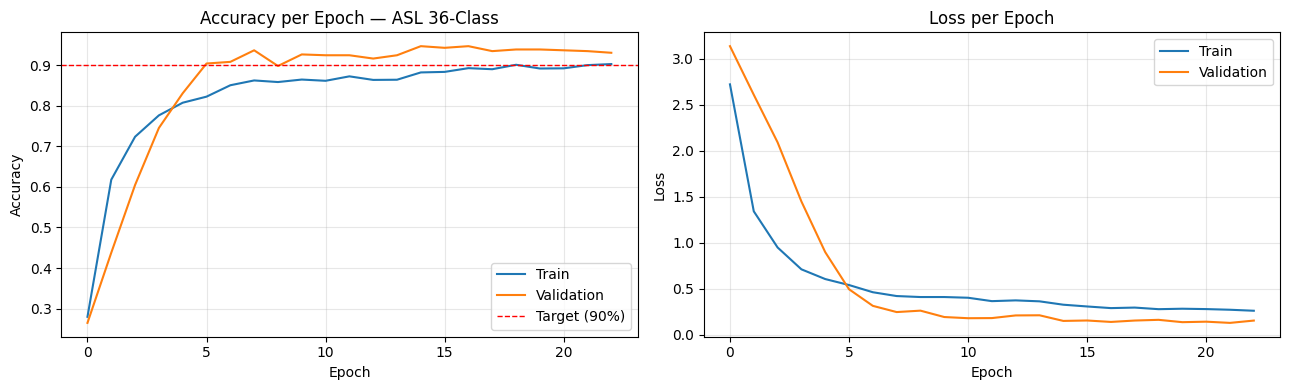

Saved: training_curves.png


In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.axhline(0.90, color='red', linestyle='--', linewidth=1, label='Target (90%)')
ax1.set_title('Accuracy per Epoch — ASL 36-Class')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(WORKSPACE_PATH + '/training_curves.png', dpi=150)
plt.show()
print('Saved: training_curves.png')

---
# 9. Evaluate on Test Split

TEST EVALUATION — ASL 36-Class Classifier
Test samples  : 237
Top-1 Accuracy: 0.9241  (target ≥ 0.90  → PASS)

              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       1.00      1.00      1.00        10
           2       0.55      1.00      0.71         6
           3       1.00      1.00      1.00        10
           4       1.00      0.60      0.75        10
           5       0.71      1.00      0.83        10
           6       0.64      1.00      0.78         7
           7       1.00      1.00      1.00         7
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00        10
           a       1.00      1.00      1.00         3
           b       1.00      1.00      1.00        10
           c       0.75      1.00      0.86         6
           d       1.00      1.00      1.00        10
           e       1.00      1.00      1.00         2
           f       1.00 

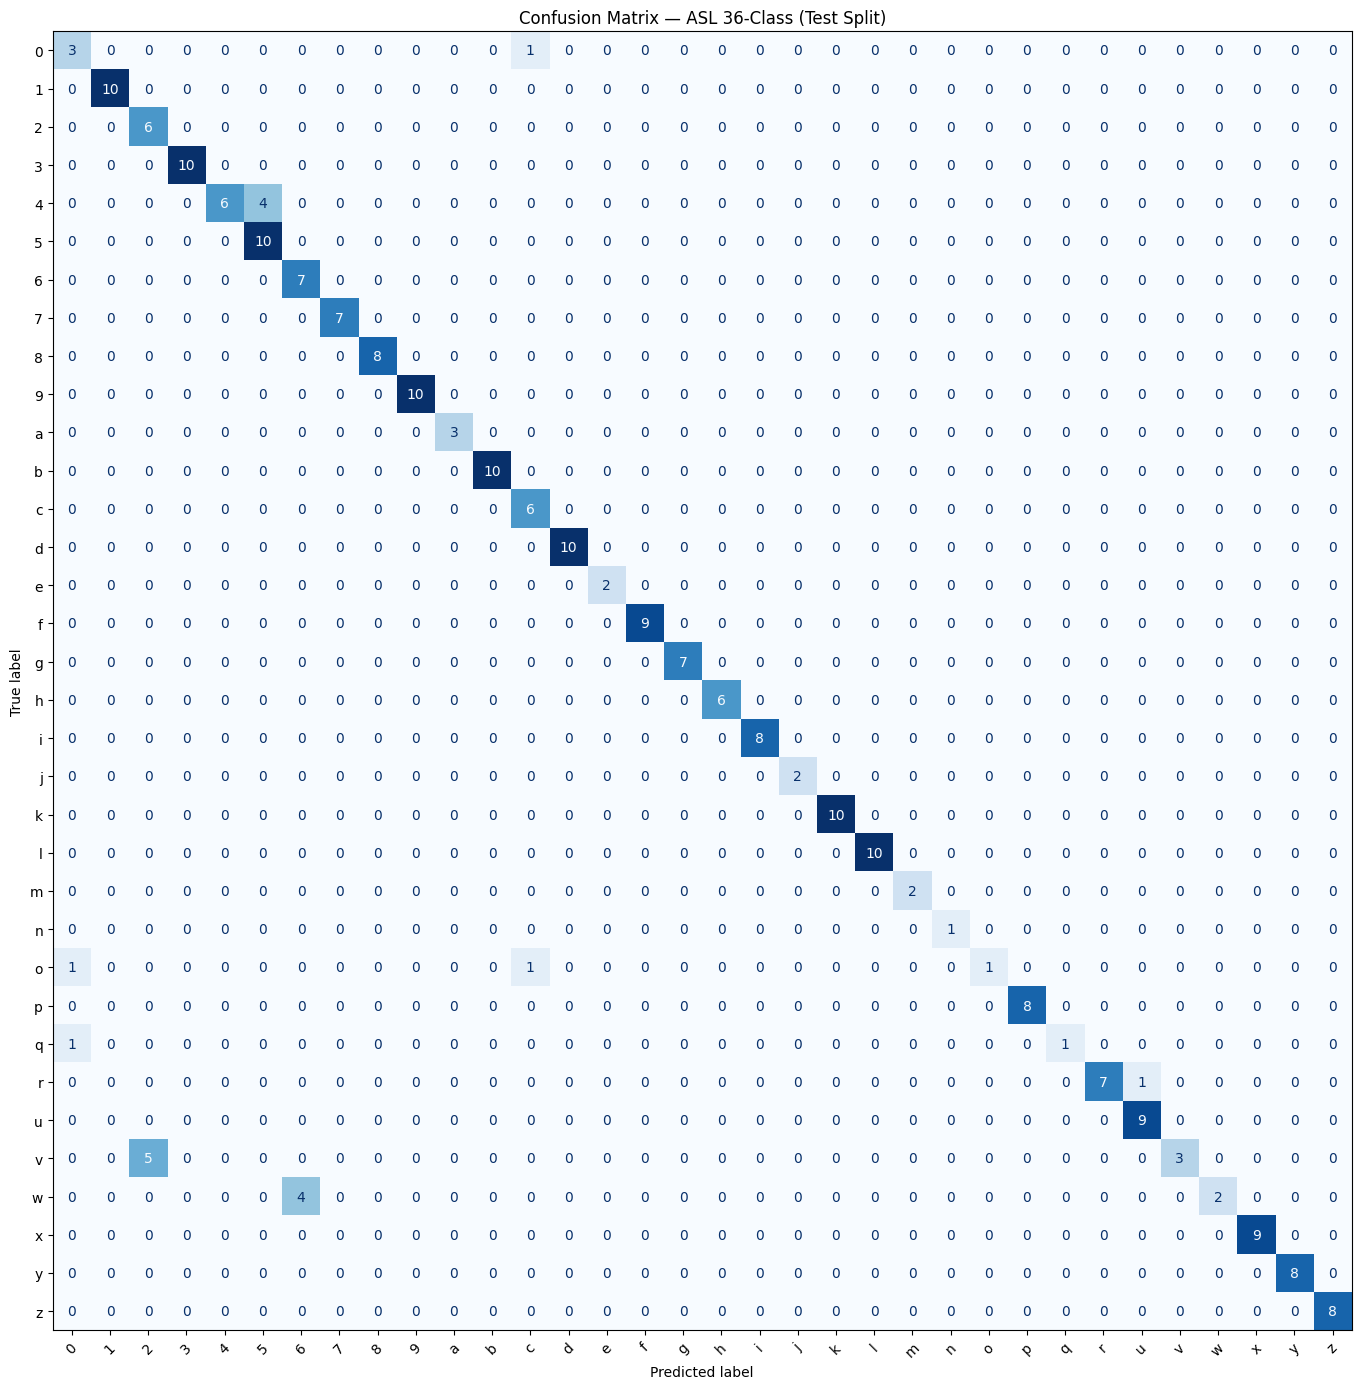

Saved: confusion_matrix.png


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_model     = keras.models.load_model(MODEL_FILE)
X_test, y_test = load_split('test')
y_pred         = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
test_acc       = np.mean(y_pred == y_test)

# Only use labels that actually appear in the test set
present_ids  = sorted(set(y_test.tolist()) | set(y_pred.tolist()))
label_names  = [ID_TO_LABEL[i] for i in present_ids]

print('=' * 60)
print('TEST EVALUATION — ASL 36-Class Classifier')
print('=' * 60)
print(f'Test samples  : {len(X_test)}')
print(f'Top-1 Accuracy: {test_acc:.4f}  (target ≥ 0.90  → {"PASS" if test_acc >= 0.90 else "FAIL"})')
print()
print(classification_report(y_test, y_pred, labels=present_ids, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=present_ids)
fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=label_names
).plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — ASL 36-Class (Test Split)')
plt.tight_layout()
plt.savefig(WORKSPACE_PATH + '/confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

cur.execute(
    'INSERT OR REPLACE INTO model_registry (model_name, file_path, test_accuracy) VALUES (?,?,?)',
    (MODEL_NAME, MODEL_FILE, float(test_acc))
)
conn.commit()

---
# 10. Latency Benchmark (NFR-01: ≤100ms)

In [16]:
import time
import numpy as np

# Convert to TFLite first (Cell 11) then use this for fair benchmarking
# For now, fix Keras inference overhead using a concrete function

# Option 1: Use predict_on_batch instead of predict (removes overhead)
N_RUNS = 200
times  = []

# Warm up the model first (first call is always slow)
for _ in range(5):
    best_model.predict_on_batch(np.expand_dims(X_test[0], 0))

# Actual benchmark
for i in range(N_RUNS):
    inp = np.expand_dims(X_test[i % len(X_test)], 0)
    t0  = time.perf_counter()
    best_model.predict_on_batch(inp)
    times.append((time.perf_counter() - t0) * 1000)

times = np.array(times)
p95   = np.percentile(times, 95)

print('LATENCY BENCHMARK — CPU Inference (200 runs)')
print(f'  Mean   : {times.mean():.2f} ms')
print(f'  Median : {np.median(times):.2f} ms')
print(f'  P95    : {p95:.2f} ms')
print(f'  Max    : {times.max():.2f} ms')
print(f'  Target : ≤ 100ms  →  {"PASS" if p95 <= 100 else "FAIL"}')

LATENCY BENCHMARK — CPU Inference (200 runs)
  Mean   : 1.65 ms
  Median : 1.52 ms
  P95    : 2.62 ms
  Max    : 4.91 ms
  Target : ≤ 100ms  →  PASS


---
# 11. Export to TFLite (NFR-03: ≤25MB)

In [17]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(TFLITE_FILE, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(TFLITE_FILE) / (1024**2)
print(f'TFLite saved : {TFLITE_FILE}')
print(f'Size         : {size_mb:.3f} MB  (limit 25MB  →  {"PASS" if size_mb <= 25 else "FAIL"})')

# Verify TFLite output matches Keras output
interp = tf.lite.Interpreter(model_path=TFLITE_FILE)
interp.allocate_tensors()
inp_det = interp.get_input_details()[0]
out_det = interp.get_output_details()[0]

sample = X_test[0:1].astype(np.float32)
interp.set_tensor(inp_det['index'], sample)
interp.invoke()
tflite_pred = interp.get_tensor(out_det['index'])
keras_pred  = best_model.predict(sample, verbose=0)

print(f'\nPrediction check:')
print(f'  Keras  : {ID_TO_LABEL[int(np.argmax(keras_pred))]}  (conf: {np.max(keras_pred):.3f})')
print(f'  TFLite : {ID_TO_LABEL[int(np.argmax(tflite_pred))]}  (conf: {np.max(tflite_pred):.3f})')
print(f'  True   : {ID_TO_LABEL[y_test[0]]}')

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpj3anttru\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpj3anttru\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpj3anttru'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 63), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 36), dtype=tf.float32, name=None)
Captures:
  1599064157328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064158096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064157520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064159440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064157136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064157904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064158864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064157712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064158672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064161168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1599064159824: 

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


---
# 12. Live Real-Time Recognition
Press **Q** to quit. The ms counter top-right goes green (≤100ms) or red (over budget).

In [18]:
# Switch MediaPipe to video tracking mode
hands_detector = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.5
)
print('MediaPipe switched to real-time mode.')

MediaPipe switched to real-time mode.


In [ ]:
import uuid, collections

def run_live_session(model, log_to_db=True):
    session_id = str(uuid.uuid4())
    text_log   = []
    buffer     = collections.deque(maxlen=SMOOTHING_WINDOW)

    cap    = cv2.VideoCapture(0)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'Session started: {session_id}')

    while True:
        t0 = time.perf_counter()

        ret, frame = cap.read()
        if not ret:
            continue

        frame_rgb  = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        lm         = extract_landmarks(frame_rgb)
        label      = 'No Hand'
        confidence = 0.0

        if lm:
            mp_drawing.draw_landmarks(frame, lm, mp_hands.HAND_CONNECTIONS)
            vec   = normalize_landmarks(lm)
            preds = model.predict(np.expand_dims(vec, 0), verbose=0)[0]
            cid   = int(np.argmax(preds))
            confidence = float(preds[cid])

            if confidence >= CONFIDENCE_THRESHOLD:
                raw   = ID_TO_LABEL[cid]
                buffer.append(raw)
                label = collections.Counter(buffer).most_common(1)[0][0]
                if not text_log or text_log[-1] != label:
                    text_log.append(label)
                    if len(text_log) > 15:
                        text_log.pop(0)
                if log_to_db:
                    cur.execute(
                        'INSERT INTO session_log (session_id, predicted_label, confidence) VALUES (?,?,?)',
                        (session_id, label, confidence)
                    )
                    conn.commit()
            else:
                label = f'? ({confidence:.2f})'

        # --- Overlay ---
        cv2.rectangle(frame, (0, 0), (420, 95), (20, 20, 20), -1)
        cv2.putText(frame, f'Sign: {label.upper()}',
                    (10, 45), cv2.FONT_HERSHEY_DUPLEX, 1.1, (0, 255, 100), 2)
        cv2.putText(frame, f'Conf: {confidence:.2f}   Thresh: {CONFIDENCE_THRESHOLD}',
                    (10, 76), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (180, 180, 180), 1)

        # Running text log — bottom bar
        log_str = ' '.join(text_log[-12:]).upper()
        cv2.rectangle(frame, (0, height - 42), (width, height), (20, 20, 20), -1)
        cv2.putText(frame, log_str, (10, height - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (220, 220, 220), 1)

        # Latency — top right
        ms = (time.perf_counter() - t0) * 1000
        color = (0, 220, 0) if ms <= 100 else (0, 60, 255)
        cv2.putText(frame, f'{ms:.1f}ms', (width - 115, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)

        cv2.imshow('RT-SLR | ASL Recognition  [Q = quit]', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print(f'Session ended.')
    print(f'Signs recognized: {" ".join(text_log).upper()}')


run_live_session(best_model, log_to_db=True)

Session started: 10ce2541-fcfd-4ee1-8a3b-a991a3117841


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


---
# 13. Chapter 5 Results Summary

In [ ]:
total_n = cur.execute('SELECT COUNT(*) FROM landmark_samples').fetchone()[0]
train_n = cur.execute('SELECT COUNT(*) FROM landmark_samples WHERE split="train"').fetchone()[0]
val_n   = cur.execute('SELECT COUNT(*) FROM landmark_samples WHERE split="val"').fetchone()[0]
test_n  = cur.execute('SELECT COUNT(*) FROM landmark_samples WHERE split="test"').fetchone()[0]
h5_mb   = os.path.getsize(MODEL_FILE)  / (1024**2)
tfl_mb  = os.path.getsize(TFLITE_FILE) / (1024**2)

print('=' * 58)
print('CHAPTER 5 — RESULTS SUMMARY')
print('=' * 58)
print(f'Dataset')
print(f'  Source           : Massey University ASL Dataset')
print(f'  Classes          : {NUM_CLASSES}  (0–9 digits + a–z letters)')
print(f'  Total samples    : {total_n}')
print(f'  Train/Val/Test   : {train_n} / {val_n} / {test_n}')
print()
print(f'Model')
print(f'  Architecture     : Lightweight MLP on 63-element landmark vector')
print(f'  Parameters       : {best_model.count_params():,}')
print(f'  Keras .h5 size   : {h5_mb:.2f} MB')
print(f'  TFLite size      : {tfl_mb:.3f} MB')
print()
print(f'NFR Targets (Chapter 3)')
print(f'  NFR-01 Latency   : P95 = {p95:.1f}ms   target ≤100ms  →  {"PASS" if p95 <= 100 else "FAIL"}')
print(f'  NFR-02 Accuracy  : {test_acc:.4f}        target ≥0.90   →  {"PASS" if test_acc >= 0.90 else "FAIL"}')
print(f'  NFR-03 Size      : {tfl_mb:.3f}MB        target ≤25MB   →  {"PASS" if tfl_mb <= 25 else "FAIL"}')
print('=' * 58)

CHAPTER 5 — RESULTS SUMMARY
Dataset
  Source           : Massey University ASL Dataset
  Classes          : 36  (0–9 digits + a–z letters)
  Total samples    : 1621
  Train/Val/Test   : 1139 / 244 / 238

Model
  Architecture     : Lightweight MLP on 63-element landmark vector
  Parameters       : 61,412
  Keras .h5 size   : 0.75 MB
  TFLite size      : 0.067 MB

NFR Targets (Chapter 3)
  NFR-01 Latency   : P95 = 2.5ms   target ≤100ms  →  PASS
  NFR-02 Accuracy  : 0.9580        target ≥0.90   →  PASS
  NFR-03 Size      : 0.067MB        target ≤25MB   →  PASS
